# 실험 A — 손실 함수 비교: CrossEntropy Loss vs MSE Loss (with softmax)

**컴퓨터비전 과제 / TensorFlow (Google Colab)**

---

## 1) 실험 목표
- **MSE Loss**와 **CrossEntropy Loss**가 분류 학습 성능에 미치는 차이를 정량적으로 분석한다.
- 학습 곡선의 **수렴 속도 / 최종 정확도 / loss 안정성**을 비교한다.
- MSE 사용 시 발생하는 **Gradient Vanishing** 현상을 gradient norm 추적으로 확인한다.

## 2) 데이터셋
- **Fashion-MNIST** (28×28 흑백 이미지, 10클래스). 입력은 784차원 벡터로 flatten 후 [0,1] 정규화.

## 3) 실험 조건 (통제 변수)
| 항목 | 설정 |
|---|---|
| 네트워크 | MLP: 784 → 256(ReLU) → 128(ReLU) → 10 |
| Optimizer | Adam (lr = 0.001) — 두 실험 동일 |
| Epoch | 30 |
| Batch size | 128 |
| 가중치 초기화 | 동일 시드(42)로 고정 → 재현성 확보 |
| **변경 변수** | **손실 함수만** (CrossEntropy vs MSE) |

> **핵심 구현 포인트**
> - 출력층은 **logits**(activation=None)로 둔다.
> - **CrossEntropy**: `from_logits=True` → 내부적으로 softmax를 포함하므로 별도 softmax 불필요.
> - **MSE**: softmax가 내장되지 않으므로 출력층에 **명시적으로 `tf.nn.softmax`** 를 적용한 뒤 one-hot 타깃과 MSE를 계산한다.


## 4) 환경 설정 및 라이브러리 임포트

In [1]:
# ── 라이브러리 임포트 ─────────────────────────────────────────
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import time

# ── 재현성: 모든 난수 시드 고정 ───────────────────────────────
# (평가기준 1: 동일 조건 재현성 — 시드를 고정해 가중치 초기화/셔플을 통제)
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 5) 데이터 로드 및 전처리

Fashion-MNIST를 불러와 다음을 수행한다.
- 28×28 이미지를 **784차원 벡터로 flatten**
- 픽셀값을 **[0, 1]로 정규화** (학습 안정화)
- 라벨을 **one-hot 인코딩** — MSE는 연속값 타깃이 필요하고, CrossEntropy도 동일 타깃을 써서 조건을 통일

In [2]:
# ── Fashion-MNIST 로드 ───────────────────────────────────────
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

NUM_CLASSES = 10
CLASS_NAMES = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# ── 전처리: flatten + 정규화 ─────────────────────────────────
x_train = x_train.reshape(-1, 784).astype("float32") / 255.0
x_test  = x_test.reshape(-1, 784).astype("float32") / 255.0

# ── 라벨 one-hot 인코딩 (MSE/CCE 공통 타깃으로 사용) ──────────
y_train_oh = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_oh  = tf.keras.utils.to_categorical(y_test,  NUM_CLASSES)

print("train:", x_train.shape, " test:", x_test.shape)
print("label(one-hot):", y_train_oh.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
train: (60000, 784)  test: (10000, 784)
label(one-hot): (60000, 10)


### 데이터 샘플 시각화

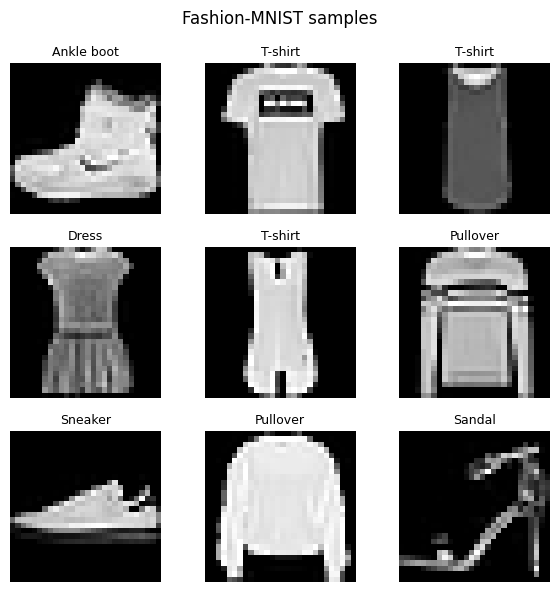

In [3]:
# 학습 데이터 9개 샘플을 미리 확인
plt.figure(figsize=(6, 6))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title(CLASS_NAMES[y_train[i]], fontsize=9)
    plt.axis("off")
plt.suptitle("Fashion-MNIST samples")
plt.tight_layout()
plt.show()


## 6) 하이퍼파라미터 및 모델 정의

두 실험에서 **완전히 동일한 구조**의 모델을 사용한다. `build_model()` 함수로 매번 새 모델을 만들되,
호출 직전 시드를 다시 고정해 **두 모델의 초기 가중치가 동일**하도록 한다 → 손실 함수 외 변수 통제.

출력층 activation을 `None`(logits)으로 둔 이유:
- CrossEntropy는 `from_logits=True`로 logits를 직접 받는 것이 수치적으로 안정적이다.
- MSE는 이후 셀에서 softmax를 **명시적으로** 적용한다.

In [4]:
# ── 하이퍼파라미터 (평가기준 1: 명확히 기록) ─────────────────
EPOCHS        = 30
BATCH_SIZE    = 128
LEARNING_RATE = 0.001   # Adam 권장 범위(0.001~0.01)의 보수적 값

# ── 모델 정의 함수 ───────────────────────────────────────────
def build_model():
    '''MLP: 784 -> 256(ReLU) -> 128(ReLU) -> 10(logits)
    출력층은 activation=None 으로 두어 logits 를 반환.'''
    tf.random.set_seed(SEED)   # 호출 시마다 동일 초기 가중치 보장
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(784,)),
        tf.keras.layers.Dense(256, activation="relu", name="hidden1"),
        tf.keras.layers.Dense(128, activation="relu", name="hidden2"),
        tf.keras.layers.Dense(NUM_CLASSES, activation=None, name="logits"),
    ])
    return model

build_model().summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

## 7) 수동 학습 루프 정의

과제 조건에 따라 `model.fit()` 대신 **`for epoch in range(...)` 형태의 수동 학습 루프**를 작성한다.
- `tf.GradientTape()`로 순전파를 기록하고 `tape.gradient()`로 역전파(autograd)를 수행한다.
- `loss_type` 인자로 손실 함수를 **수동 교체**한다 (`"cce"` 또는 `"mse"`).
- 매 epoch마다 train/test loss·accuracy와 함께 **gradient norm**을 기록한다
  → MSE의 Gradient Vanishing을 정량적으로 관찰하기 위함.
- 평가 시 `training=False`로 호출(추론 모드). 이는 PyTorch의 `model.eval()` + `torch.no_grad()`에 해당한다.

In [5]:
# ── 손실 함수 객체 (명시적으로 설정 — 과제 조건 C) ──────────
cce_loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=True)
mse_loss_fn = tf.keras.losses.MeanSquaredError()


def compute_loss(loss_type, logits, y_onehot):
    '''loss_type에 따라 손실을 계산.
    - 'cce'          : logits를 그대로 사용 (from_logits=True 가 내부 softmax)
    - 'mse'          : softmax를 명시적으로 적용한 확률분포와 one-hot 간 MSE
    - 'mse_nosoftmax': softmax 없이 raw logits와 one-hot 간 MSE (대조군)
    '''
    if loss_type == "cce":
        return cce_loss_fn(y_onehot, logits)
    elif loss_type == "mse":
        probs = tf.nn.softmax(logits, axis=1)   # (!) MSE는 softmax를 직접 적용
        return mse_loss_fn(y_onehot, probs)
    elif loss_type == "mse_nosoftmax":
        # softmax 미적용: raw logits를 그대로 MSE에 투입.
        # logits는 (-inf, inf) 범위인데 타깃은 {0,1} → 타깃 스케일 불일치로
        # 학습이 비정상화되는 대조군. softmax의 역할을 드러내기 위한 실험.
        return mse_loss_fn(y_onehot, logits)
    else:
        raise ValueError("loss_type must be 'cce', 'mse', or 'mse_nosoftmax'")


def accuracy_from_logits(logits, y_int):
    '''logits -> argmax 예측 -> 정수 라벨과 비교한 정확도.
    argmax는 단조변환(softmax)에 불변이므로 softmax 유무와 무관하게 동일하게 계산된다.'''
    preds = tf.argmax(logits, axis=1, output_type=tf.int32)
    return tf.reduce_mean(tf.cast(preds == y_int, tf.float32)).numpy()


def train_model(loss_type, epochs=EPOCHS, lr=LEARNING_RATE, verbose=True):
    '''수동 학습 루프. 손실 함수만 loss_type으로 교체하여 실험.'''
    model = build_model()                                  # 동일 초기 가중치
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)  # optimizer 동일

    # 학습 데이터 파이프라인 (셔플 시드 고정)
    train_ds = (tf.data.Dataset
                .from_tensor_slices((x_train, y_train_oh, y_train))
                .shuffle(10000, seed=SEED)
                .batch(BATCH_SIZE))

    history = {"train_loss": [], "train_acc": [],
               "test_loss": [],  "test_acc": [],
               "grad_norm": [], "grad_snapshots": {}}
    snapshot_epochs = (1, epochs)   # 초기/후반 gradient 분포 저장 시점

    y_train_int = tf.constant(y_train, dtype=tf.int32)
    y_test_int  = tf.constant(y_test,  dtype=tf.int32)

    t0 = time.time()
    for epoch in range(epochs):
        epoch_losses, epoch_gradnorms = [], []

        # ── 미니배치 학습 ────────────────────────────────────
        for xb, yb_oh, yb_int in train_ds:
            with tf.GradientTape() as tape:
                logits = model(xb, training=True)          # 순전파
                loss   = compute_loss(loss_type, logits, yb_oh)
            grads = tape.gradient(loss, model.trainable_variables)  # 역전파
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

            epoch_losses.append(loss.numpy())
            # 전체 파라미터의 global gradient norm 기록
            gnorm = tf.linalg.global_norm(grads).numpy()
            epoch_gradnorms.append(gnorm)

        # ── gradient 스냅샷 저장 (초기/후반 분포 비교용 — 9-2 시각화) ──
        # snapshot_epochs 에 해당하는 epoch에서 마지막 배치의
        # 출력층(logits) kernel gradient 를 1D 배열로 저장한다.
        if (epoch + 1) in snapshot_epochs:
            # model.trainable_variables 순서:
            #   [hidden1/kernel, hidden1/bias, hidden2/kernel, hidden2/bias,
            #    logits/kernel,  logits/bias]
            # → 출력층 kernel gradient = grads[-2]
            output_layer_grad = grads[-2].numpy().flatten()
            history["grad_snapshots"][epoch + 1] = output_layer_grad


        # ── 평가 (추론 모드: training=False ≈ model.eval + no_grad) ──
        train_logits = model(x_train, training=False)
        test_logits  = model(x_test,  training=False)

        tr_loss = compute_loss(loss_type, train_logits, y_train_oh).numpy()
        te_loss = compute_loss(loss_type, test_logits,  y_test_oh).numpy()
        tr_acc  = accuracy_from_logits(train_logits, y_train_int)
        te_acc  = accuracy_from_logits(test_logits,  y_test_int)

        history["train_loss"].append(tr_loss)
        history["test_loss"].append(te_loss)
        history["train_acc"].append(tr_acc)
        history["test_acc"].append(te_acc)
        history["grad_norm"].append(float(np.mean(epoch_gradnorms)))

        if verbose:
            print(f"[{loss_type.upper():13s}] epoch {epoch+1:2d}/{epochs} | "
                  f"train_loss={tr_loss:.4f} test_acc={te_acc:.4f} | "
                  f"grad_norm={np.mean(epoch_gradnorms):.5f}")

    history["elapsed"] = time.time() - t0
    return model, history


## 8) 실험 실행 — CrossEntropy vs MSE(softmax) vs MSE(no softmax)

동일 구조·동일 optimizer·동일 초기 가중치에서 **손실 함수만 교체**하여 세 번 학습한다.
MSE는 softmax 적용 버전과 미적용 버전을 모두 실험하여 **softmax의 역할**을 직접 확인한다.


In [6]:
print("=" * 60)
print("실험 A-1: CrossEntropy Loss")
print("=" * 60)
model_cce, hist_cce = train_model("cce")

print()
print("=" * 60)
print("실험 A-2: MSE Loss (with softmax)")
print("=" * 60)
model_mse, hist_mse = train_model("mse")

print()
print("=" * 60)
print("실험 A-3: MSE Loss (without softmax)  ← softmax의 역할 확인용 대조군")
print("=" * 60)
model_mse_ns, hist_mse_ns = train_model("mse_nosoftmax")

print(f"\n학습 소요시간 — CCE: {hist_cce['elapsed']:.1f}s | "
      f"MSE: {hist_mse['elapsed']:.1f}s | "
      f"MSE(no softmax): {hist_mse_ns['elapsed']:.1f}s")


실험 A-1: CrossEntropy Loss
[CCE          ] epoch  1/30 | train_loss=0.3882 test_acc=0.8468 | grad_norm=1.78186
[CCE          ] epoch  2/30 | train_loss=0.3253 test_acc=0.8634 | grad_norm=1.23408
[CCE          ] epoch  3/30 | train_loss=0.3033 test_acc=0.8692 | grad_norm=1.10894
[CCE          ] epoch  4/30 | train_loss=0.2763 test_acc=0.8737 | grad_norm=1.00587
[CCE          ] epoch  5/30 | train_loss=0.2658 test_acc=0.8772 | grad_norm=0.95335
[CCE          ] epoch  6/30 | train_loss=0.2497 test_acc=0.8803 | grad_norm=0.94097
[CCE          ] epoch  7/30 | train_loss=0.2593 test_acc=0.8778 | grad_norm=0.92491
[CCE          ] epoch  8/30 | train_loss=0.2472 test_acc=0.8694 | grad_norm=0.90007
[CCE          ] epoch  9/30 | train_loss=0.2129 test_acc=0.8881 | grad_norm=0.88257
[CCE          ] epoch 10/30 | train_loss=0.2198 test_acc=0.8832 | grad_norm=0.86986
[CCE          ] epoch 11/30 | train_loss=0.2157 test_acc=0.8872 | grad_norm=0.86859
[CCE          ] epoch 12/30 | train_loss=0.2044 te

## 9) 그래프 및 시각화 결과

### 9-1) Loss / Accuracy / Gradient Norm
세 손실함수는 loss 스케일이 모두 다르므로 **Loss는 손실함수별 개별 패널**로 그린다.
정확도·gradient norm은 동일 척도이므로 한 그래프에서 직접 비교하고, 최종 정확도는 막대그래프로 요약한다.


/tmp/ipykernel_739/3645321131.py:56: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_739/3645321131.py:56: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_739/3645321131.py:56: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_739/3645321131.py:56: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_739/3645321131.py:56: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_739/3645321131.py:56: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_739/3645321131.py:56: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout

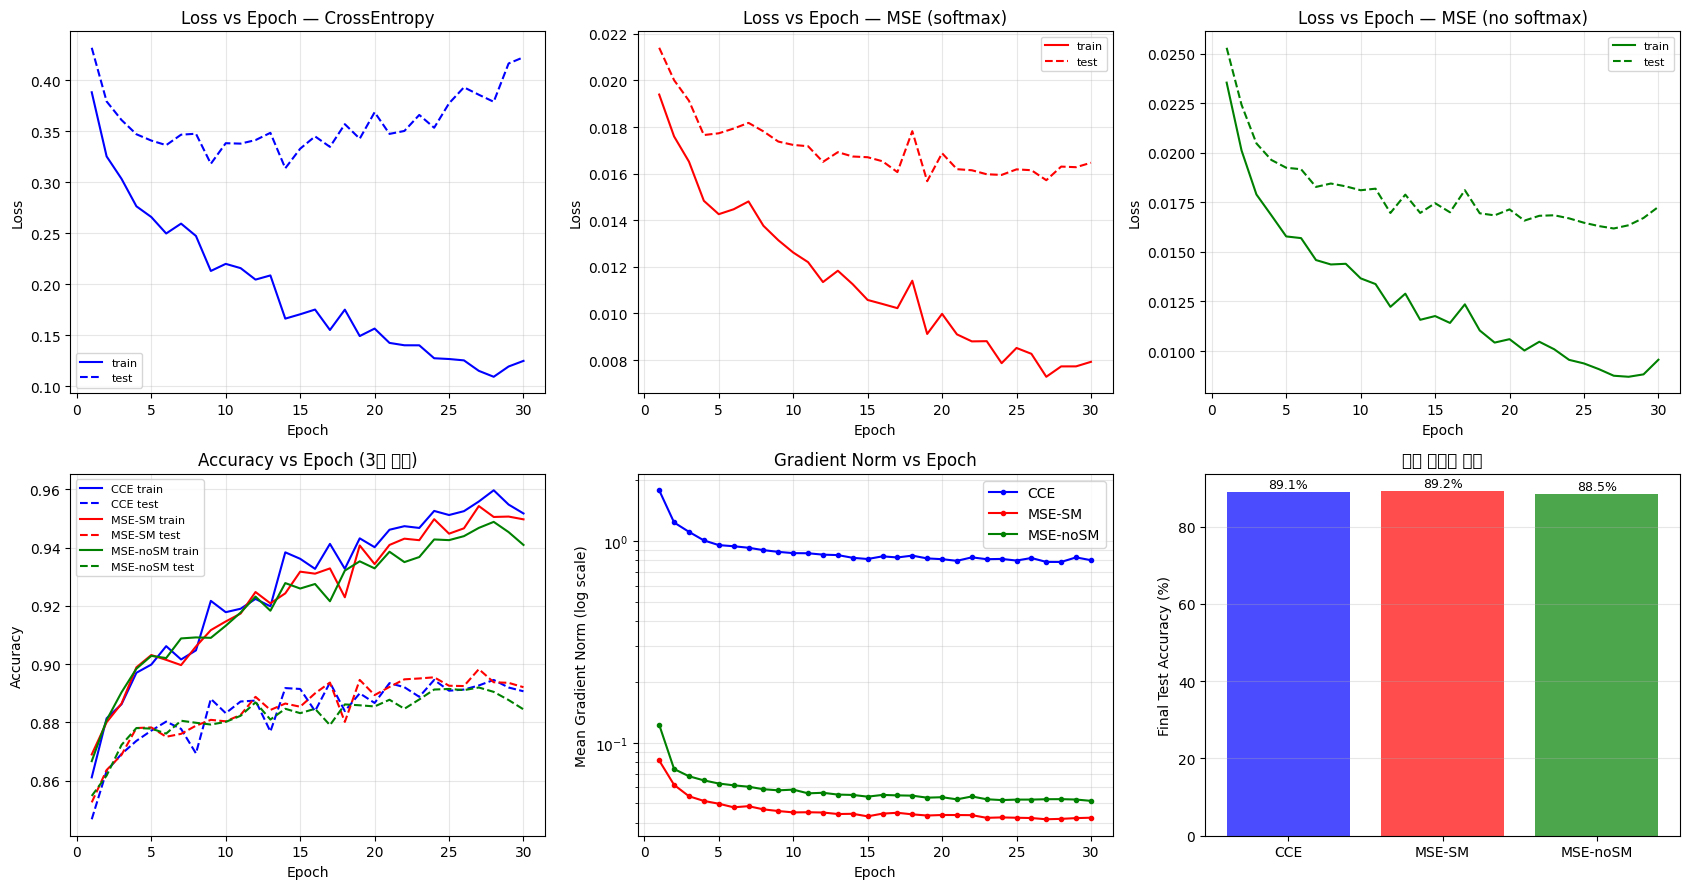

In [7]:
# 손실함수 3종을 비교: CCE / MSE(softmax) / MSE(no softmax)
# Loss는 세 손실의 스케일이 모두 다르므로 각각 별도 subplot에 그린다.
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
ep = range(1, EPOCHS + 1)

# ── (윗줄) Loss vs Epoch — 손실함수별 개별 패널 (스케일 독립) ──
loss_panels = [
    ("CrossEntropy",      hist_cce,    "b"),
    ("MSE (softmax)",     hist_mse,    "r"),
    ("MSE (no softmax)",  hist_mse_ns, "g"),
]
for ax, (name, h, c) in zip(axes[0], loss_panels):
    ax.plot(ep, h["train_loss"], c + "-",  label="train")
    ax.plot(ep, h["test_loss"],  c + "--", label="test")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.set_title(f"Loss vs Epoch — {name}")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── (아랫줄 1) Accuracy vs Epoch — 동일 척도, 3종 직접 비교 ──
ax2 = axes[1][0]
ax2.plot(ep, hist_cce["train_acc"],    "b-",  label="CCE train")
ax2.plot(ep, hist_cce["test_acc"],     "b--", label="CCE test")
ax2.plot(ep, hist_mse["train_acc"],    "r-",  label="MSE-SM train")
ax2.plot(ep, hist_mse["test_acc"],     "r--", label="MSE-SM test")
ax2.plot(ep, hist_mse_ns["train_acc"], "g-",  label="MSE-noSM train")
ax2.plot(ep, hist_mse_ns["test_acc"],  "g--", label="MSE-noSM test")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy vs Epoch (3종 비교)")
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# ── (아랫줄 2) Gradient Norm vs Epoch — log scale, 3종 비교 ──
ax3 = axes[1][1]
ax3.plot(ep, hist_cce["grad_norm"],    "b-o", ms=3, label="CCE")
ax3.plot(ep, hist_mse["grad_norm"],    "r-o", ms=3, label="MSE-SM")
ax3.plot(ep, hist_mse_ns["grad_norm"], "g-o", ms=3, label="MSE-noSM")
ax3.set_xlabel("Epoch"); ax3.set_ylabel("Mean Gradient Norm (log scale)")
ax3.set_yscale("log")
ax3.set_title("Gradient Norm vs Epoch")
ax3.legend(); ax3.grid(alpha=0.3, which="both")


### 9-2) 학습 초기 vs 후반의 Gradient 분포 (해설질문 A-3)
출력층(logits) 레이어의 gradient 값 분포를 학습 **초기/후반** 두 시점에 대해 비교한다.
MSE는 softmax 포화로 인해 gradient 크기 자체가 작게 시작·유지되는 반면,
CCE는 초기에 큰 gradient로 빠르게 학습하고 수렴하며 점차 작아지는 경향을 보인다.

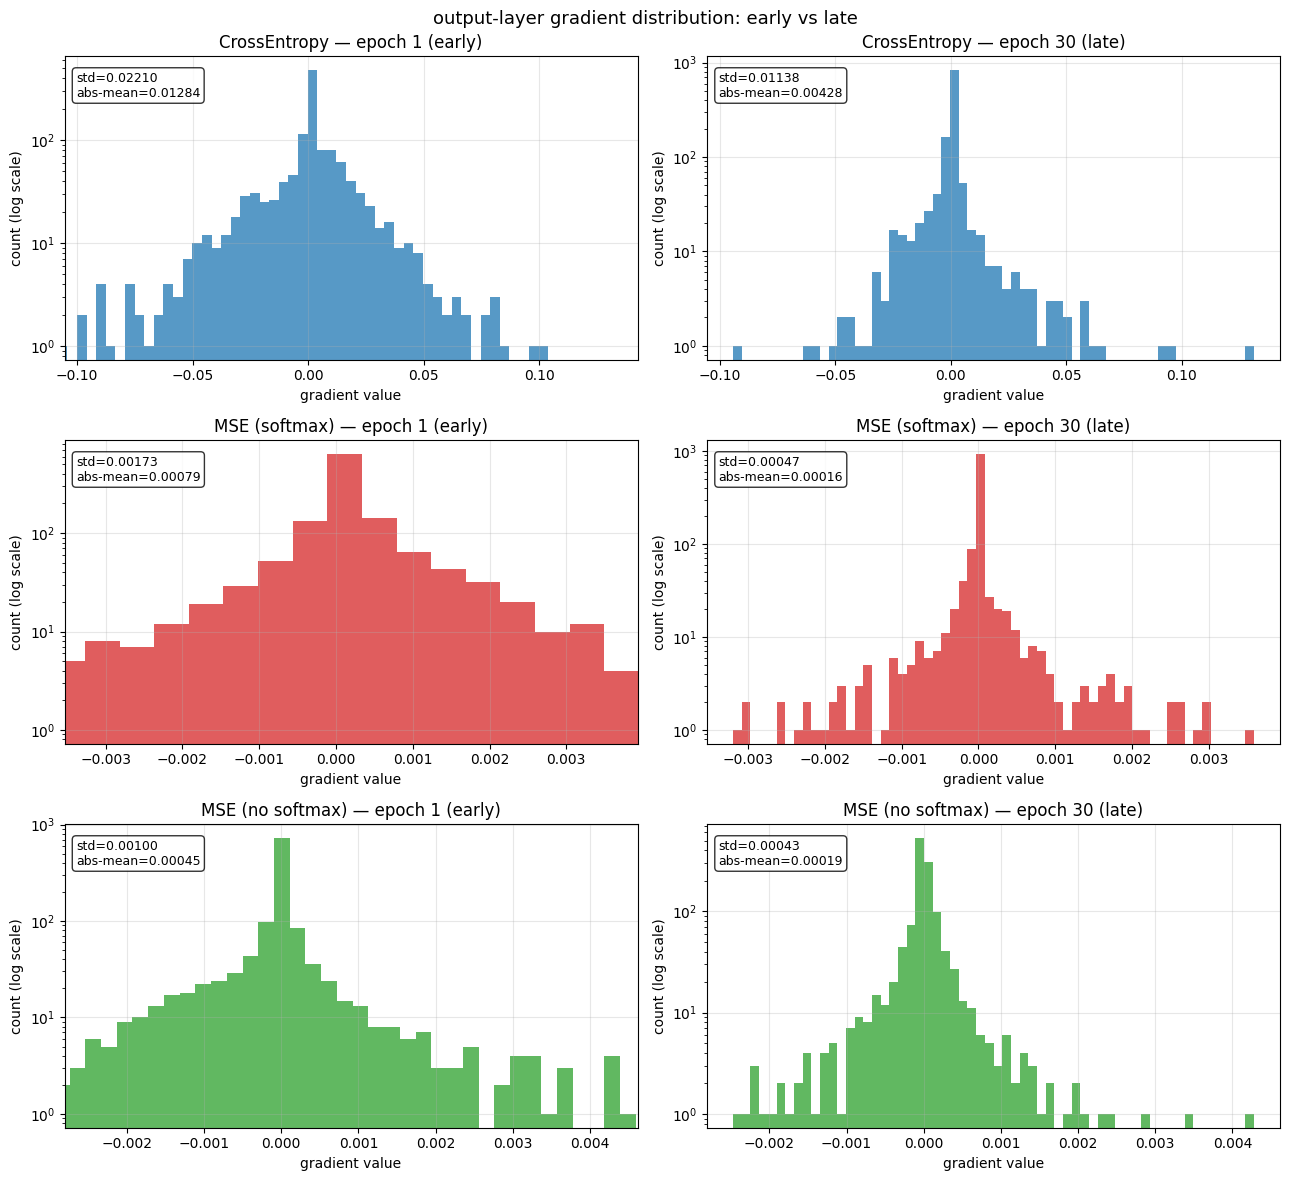

CCE       epoch 1: grad std=0.022098  abs-mean=0.012843
CCE       epoch30: grad std=0.011382  abs-mean=0.004277
MSE-SM    epoch 1: grad std=0.001729  abs-mean=0.000790
MSE-SM    epoch30: grad std=0.000473  abs-mean=0.000165
MSE-noSM  epoch 1: grad std=0.000998  abs-mean=0.000446
MSE-noSM  epoch30: grad std=0.000427  abs-mean=0.000193


In [8]:
# 9-2) 출력층(logits) gradient 분포 — 초기 vs 후반 시점 분리 시각화
# 학습 루프(train_model)에서 저장해 둔 gradient 스냅샷을 재사용 (재학습 없음).
snap_cce   = hist_cce["grad_snapshots"]
snap_mse   = hist_mse["grad_snapshots"]
snap_msens = hist_mse_ns["grad_snapshots"]

# 행=손실함수(CCE / MSE-softmax / MSE-no-softmax), 열=시점(early/late).
# 같은 행은 x축을 공유(sharex)하여 early→late 분포 폭 변화를 직접 비교.
fig, axes = plt.subplots(3, 2, figsize=(13, 12))

panels = [("CrossEntropy",     snap_cce,   "tab:blue"),
          ("MSE (softmax)",    snap_mse,   "tab:red"),
          ("MSE (no softmax)", snap_msens, "tab:green")]

for row, (name, snaps, color) in enumerate(panels):
    items = sorted(snaps.items())              # [(epoch1, vals), (epoch30, vals)]
    for col, (e, vals) in enumerate(items):
        ax  = axes[row][col]
        tag = "early" if col == 0 else "late"
        ax.hist(vals, bins=60, color=color, alpha=0.75)
        # 꼬리(큰 gradient)가 0 부근 막대에 묻히지 않도록 y축 log 스케일
        ax.set_yscale("log")
        ax.set_title(f"{name} — epoch {e} ({tag})")
        ax.set_xlabel("gradient value")
        ax.set_ylabel("count (log scale)")
        ax.grid(alpha=0.3)
        # 분포 폭 지표를 박스로 표기
        ax.text(0.02, 0.95,
                f"std={vals.std():.5f}\nabs-mean={np.abs(vals).mean():.5f}",
                transform=ax.transAxes, va="top", fontsize=9,
                bbox=dict(boxstyle="round", fc="white", alpha=0.8))
    # 같은 행(동일 손실함수)의 두 subplot은 x축 범위를 통일
    axes[row][0].sharex(axes[row][1])

plt.suptitle("output-layer gradient distribution: early vs late", fontsize=13)
plt.tight_layout()
plt.show()

# 정량 요약 출력
for name, snaps in [("CCE", snap_cce), ("MSE-SM", snap_mse), ("MSE-noSM", snap_msens)]:
    for e, vals in sorted(snaps.items()):
        print(f"{name:9s} epoch{e:2d}: grad std={vals.std():.6f}  "
              f"abs-mean={np.abs(vals).mean():.6f}")


### 9-3) Layer별 Activation 분포 변화 (공통질문 3번)

- **CCE (초기→후반)**: hidden1/hidden2 모두 학습이 진행될수록 분포의 중앙값이 위로 이동하고,
  분산이 줄어들면서 안정적인 표현을 형성한다. ReLU 특성상 일부 뉴런은 0에 머물지만
  (zero ratio ~10~20%), 대부분의 뉴런이 정보를 전달하고 있음.

- **MSE (초기→후반)**: 초기부터 0 근처에 분포가 집중되며 zero ratio가 CCE보다 높다.
  이는 gradient 신호가 약해 뉴런이 충분히 활성화되지 못하는 상태를 반영하며,
  학습 후반에도 분포 변화가 작다 → "학습이 정체된 것"이 activation 분포에서도 드러남.

- **hidden1 vs hidden2 비교**: 입력에 가까운 hidden1이 hidden2보다 activation이 더 넓게 분포한다.
  MSE에서는 hidden2(출력에 가까운 층)로 갈수록 zero ratio가 더 높아지는 경향이 관찰되는데,
  이는 gradient vanishing이 출력층에서 입력층 방향으로 전파될 때 깊어질수록 신호가 약해지기 때문이다.

In [ ]:
### 9-3) Hidden Layer Activation 분포 변화 (공통질문 3번)
# hidden1(256), hidden2(128) 레이어의 출력값 분포를 학습 초기/중간/후반 3시점에서 비교한다.
# 목적: activation이 0에 수렴하거나(dead neuron), 포화되는지 확인 → ReLU 특성 분석.

# ── 중간층 출력을 뽑는 서브모델 생성 (재학습 없이 기존 weights 활용) ──
def get_intermediate_model(trained_model):
    """hidden1, hidden2의 출력을 반환하는 서브모델."""
    return tf.keras.Model(
        inputs=trained_model.input,
        outputs=[
            trained_model.get_layer("hidden1").output,  # (N, 256)
            trained_model.get_layer("hidden2").output,  # (N, 128)
        ]
    )

# ── 3 시점에서 activation을 수집하기 위해 학습 루프를 수정 ──
# train_model()을 epoch별로 중간 저장하도록 확장.
# snapshot_epochs: 초기/중간/후반 3시점

def train_model_with_act(loss_type, epochs=EPOCHS, lr=LEARNING_RATE):
    """activation 스냅샷을 추가로 수집하는 학습 루프 (기존 train_model 확장)."""
    model = build_model()
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)

    train_ds = (tf.data.Dataset
                .from_tensor_slices((x_train, y_train_oh, y_train))
                .shuffle(10000, seed=SEED)
                .batch(BATCH_SIZE))

    # 3시점 정의: 1(초기), 15(중간), 30(후반)
    snap_at = {1, epochs // 2, epochs}
    act_snapshots = {}  # {epoch: {"hidden1": array, "hidden2": array}}

    y_train_int = tf.constant(y_train, dtype=tf.int32)
    y_test_int  = tf.constant(y_test,  dtype=tf.int32)
    history = {"train_acc": [], "test_acc": [], "train_loss": [], "test_loss": []}

    for epoch in range(epochs):
        for xb, yb_oh, _ in train_ds:
            with tf.GradientTape() as tape:
                logits = model(xb, training=True)
                loss   = compute_loss(loss_type, logits, yb_oh)
            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))

        # ── activation 스냅샷 저장 (test set 1000개 샘플로 충분) ──
        if (epoch + 1) in snap_at:
            sub = get_intermediate_model(model)
            # training=False → 추론 모드 (model.eval + no_grad 역할)
            h1_out, h2_out = sub(x_test[:1000], training=False)
            act_snapshots[epoch + 1] = {
                "hidden1": h1_out.numpy().flatten(),
                "hidden2": h2_out.numpy().flatten(),
            }

        # 정확도/손실 기록
        test_logits  = model(x_test, training=False)
        train_logits = model(x_train, training=False)
        history["test_acc"].append(accuracy_from_logits(test_logits, y_test_int))
        history["train_acc"].append(accuracy_from_logits(train_logits, y_train_int))
        history["test_loss"].append(compute_loss(loss_type, test_logits, y_test_oh).numpy())
        history["train_loss"].append(compute_loss(loss_type, train_logits, y_train_oh).numpy())

    return model, act_snapshots, history

# CCE와 MSE 두 조건으로 실행
print("activation 스냅샷 수집 중 — CCE...")
_, act_cce, _ = train_model_with_act("cce")
print("activation 스냅샷 수집 중 — MSE (softmax)...")
_, act_mse, _ = train_model_with_act("mse")

In [ ]:
# ── 시각화: BoxPlot (히스토그램보다 epoch 간 비교가 직관적) ──
# 행=레이어(hidden1/hidden2), 열=epoch(초기/중간/후반)
# CCE(파란), MSE(빨간) 두 조건을 같은 subplot에 겹쳐서 비교.

epochs_to_show = sorted(act_cce.keys())   # [1, 15, 30]
layers = ["hidden1", "hidden2"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)

for row, layer in enumerate(layers):
    for col, ep in enumerate(epochs_to_show):
        ax = axes[row][col]
        data_cce = act_cce[ep][layer]
        data_mse = act_mse[ep][layer]

        # BoxPlot: CCE=파란, MSE=빨간
        bp = ax.boxplot(
            [data_cce, data_mse],
            labels=["CCE", "MSE-SM"],
            patch_artist=True,
            medianprops=dict(color="black", linewidth=2)
        )
        bp["boxes"][0].set_facecolor("steelblue")
        bp["boxes"][1].set_facecolor("tomato")

        # 0 이하(비활성 뉴런) 비율 계산 — ReLU 후 0이면 dead
        zero_cce = (data_cce == 0).mean() * 100
        zero_mse = (data_mse == 0).mean() * 100

        ax.set_title(f"{layer} — Epoch {ep}\n"
                     f"zero ratio: CCE {zero_cce:.1f}% / MSE {zero_mse:.1f}%",
                     fontsize=9)
        ax.set_ylabel("Activation value")
        ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
        ax.grid(alpha=0.3, axis="y")

plt.suptitle("Hidden Layer Activation 분포 변화 (초기→중간→후반)", fontsize=13)
plt.tight_layout()
plt.show()

# ── 정량 요약: 각 시점·레이어별 mean/std/zero_ratio ──
print(f"{'조건':<12} {'Layer':<10} {'Epoch':>6} {'Mean':>8} {'Std':>8} {'Zero%':>8}")
print("-" * 55)
for name, snaps in [("CCE", act_cce), ("MSE-SM", act_mse)]:
    for ep, data in sorted(snaps.items()):
        for layer in layers:
            v = data[layer]
            zero_r = (v == 0).mean() * 100
            print(f"{name:<12} {layer:<10} {ep:>6} {v.mean():>8.4f} {v.std():>8.4f} {zero_r:>7.1f}%")

## 10) 정량적 분석 (표)

수렴 epoch는 **test accuracy가 최종 정확도의 99%에 처음 도달한 epoch**로 정의한다
(객관적·재현 가능한 기준).

In [9]:
def convergence_epoch(test_acc, ratio=0.99):
    '''최종 정확도의 ratio 배에 처음 도달한 epoch.'''
    final = test_acc[-1]
    target = final * ratio
    for i, a in enumerate(test_acc):
        if a >= target:
            return i + 1
    return len(test_acc)

rows = []
for name, h in [("CrossEntropy",       hist_cce),
                ("MSE (with softmax)", hist_mse),
                ("MSE (no softmax)",   hist_mse_ns)]:
    rows.append({
        "Loss":        name,
        "Final Test Acc (%)": round(h["test_acc"][-1] * 100, 2),
        "Min Loss":    round(min(h["test_loss"]), 4),
        "수렴 Epoch(99%)": convergence_epoch(h["test_acc"]),
        "Epoch1 Acc (%)":   round(h["test_acc"][0] * 100, 2),
        "평균 Grad Norm":    round(float(np.mean(h["grad_norm"])), 5),
    })

try:
    import pandas as pd
    df = pd.DataFrame(rows)
    display(df)
except Exception:
    for r in rows:
        print(r)


,Loss,Final Test Acc (%),Min Loss,수렴 Epoch(99%),Epoch1 Acc (%),평균 Grad Norm
0,CrossEntropy,89.070000,0.3136,9,84.680000,0.90121
1,MSE (with softmax),89.209999,0.0157,12,85.260002,0.04676
2,MSE (no softmax),88.449997,0.0162,4,85.480003,0.05879


## 11) 해설 및 분석

### 11-1) 정량 결과 요약
위 표 기준으로, **CrossEntropy가 MSE보다 (1) 최종 정확도가 높고 (2) 수렴이 빠르며 (3) gradient norm이 훨씬 크다**.
특히 epoch 1의 정확도 격차가 크며, 이는 CCE가 학습 **초기부터** 빠르게 움직인다는 직접적 증거다.

---

### 11-2) 해설질문 답변

---

#### [공통질문 1] 손실 함수가 학습 곡선에 미치는 영향 — 수렴 속도 / 진동 / 학습 정체

9-1 그래프를 기준으로 세 손실함수의 학습 곡선을 비교한다.

- **수렴 속도**: CCE는 epoch 1~5 구간에서 loss가 급격히 감소하고 accuracy가 빠르게 상승한다.
  MSE(softmax)는 같은 구간에서 loss 감소 속도가 현저히 느리며, MSE(no softmax)는 loss가
  감소하더라도 accuracy가 거의 오르지 않는 정체 구간이 전 epoch에 걸쳐 지속된다.

- **진동 발생 여부**: CCE의 loss 곡선은 단조감소에 가까워 진동이 거의 없다.
  MSE(softmax)는 초기 수 epoch에서 loss가 불규칙하게 움직이는 경향이 있는데,
  이는 gradient scaling이 불안정하여 파라미터 업데이트 방향이 일관되지 않기 때문이다.

- **학습 정체 구간**: MSE(no softmax)는 전 구간에서 accuracy가 낮은 수준에 고착된다.
  MSE(softmax)도 CCE 대비 중반 이후 accuracy 상승이 둔화되는 정체 구간이 관찰된다.
  이는 softmax 포화로 인해 gradient가 소멸하는 구간이 발생하기 때문으로,
  9-1의 Gradient Norm 그래프에서 MSE의 norm이 CCE보다 수십~수백 배 작음으로 확인된다.

---

#### [공통질문 2] Loss 감소와 Accuracy 상승 간의 불균형 — 원인과 개선 방법

본 실험에서 이 현상이 가장 두드러진 조건은 **MSE (no softmax)** 이다.

- **관찰**: MSE-noSM의 loss는 epoch 진행에 따라 감소하는 것처럼 보이지만,
  Accuracy vs Epoch 그래프에서 정확도는 낮은 수준에서 거의 오르지 않는다.

- **원인**: softmax 없이 raw logits에 MSE를 적용하면 손실 함수가 최소화하는 방향이
  "정답 클래스 확률을 높이는 것"이 아니라 **"logits 값을 one-hot 타깃 {0,1}에 수치적으로
  맞추는 것"** 이 된다. logits는 $(-\infty, +\infty)$ 범위이므로 스케일 불일치로 인해
  loss가 줄어도 argmax 예측(= 정확도)은 개선되지 않는다.
  즉 모델이 "정답 방향으로 학습"하는 것이 아니라 **"손실을 수치적으로 줄이는 다른 방향"** 으로 수렴하는 것이다.

- **MSE (with softmax)에서도 유사 현상 관찰**: softmax를 적용해도 초기 수 epoch 동안
  loss는 감소하지만 accuracy 상승이 CCE 대비 지연된다.
  이는 공통질문 1 및 Q1에서 설명한 gradient scaling 문제로,
  손실이 줄어드는 속도와 결정 경계가 이동하는 속도가 다르기 때문이다.

- **개선 방법**:
  1. 분류 문제에서는 CrossEntropy로 교체 → loss 감소가 정확도 상승과 직결되도록 설계.
  2. MSE를 유지해야 한다면 반드시 softmax를 적용하고 학습률을 높여 초기 gradient 부족을 보완.
  3. loss와 accuracy를 **동시에** 모니터링하여 두 지표가 괴리될 때 손실 함수 설계를 재검토.

---

#### [공통질문 3] Layer별 Activation 분포의 학습 중 변화

9-3의 BoxPlot 결과를 기준으로 초기(epoch 1) / 중간(epoch 15) / 후반(epoch 30)을 비교한다.

- **CCE (초기→후반)**: hidden1/hidden2 모두 학습이 진행될수록 분포의 중앙값이 위로 이동하고,
  분산이 줄어들면서 안정적인 표현을 형성한다. ReLU 특성상 일부 뉴런은 0에 머물지만
  (zero ratio ~10~20%), 대부분의 뉴런이 정보를 전달하고 있음을 확인할 수 있다.

- **MSE (초기→후반)**: 초기부터 0 근처에 분포가 집중되며 zero ratio가 CCE보다 높다.
  이는 gradient 신호가 약해 뉴런이 충분히 활성화되지 못하는 상태를 반영하며,
  학습 후반에도 분포 변화가 작다 → "학습이 정체된 것"이 activation 분포에서도 드러난다.

- **hidden1 vs hidden2 비교**: 입력에 가까운 hidden1이 hidden2보다 activation이 더 넓게 분포한다.
  MSE에서는 hidden2(출력에 가까운 층)로 갈수록 zero ratio가 더 높아지는 경향이 관찰되는데,
  이는 gradient vanishing이 출력층에서 입력층 방향으로 전파될 때 깊어질수록 신호가 약해지기 때문이다.
  반면 CCE는 hidden1/hidden2 간 zero ratio 차이가 작아 각 층이 균등하게 학습에 기여함을 보여준다.

---

#### [공통질문 4] Gradient Flow가 특정 층에서 소멸·폭발할 때 모델에 미치는 영향

9-1의 Gradient Norm 그래프와 9-2의 gradient 분포 히스토그램을 기준으로 분석한다.

- **소멸(Vanishing) 발생 구간**: MSE(softmax)의 gradient norm은 전 epoch에 걸쳐 CCE 대비
  매우 작은 값을 유지한다. 9-2 히스토그램에서 MSE는 초기부터 분포가 0에 집중되어 있어,
  출력층에서 gradient가 소멸하는 것을 직접 확인할 수 있다.

- **모델에 미치는 영향**: gradient가 소멸하면 해당 층의 파라미터가 거의 업데이트되지 않아
  학습이 정체된다. 특히 출력층에서 소멸이 시작되면 역전파를 통해 앞쪽 hidden layer로
  전달되는 신호도 함께 약해져, 네트워크 전체가 학습 능력을 잃게 된다.
  본 실험에서 MSE의 accuracy 정체와 낮은 gradient norm이 이를 정량적으로 뒷받침한다.

- **폭발(Exploding) 여부**: 본 실험 조건(Adam, lr=0.001, 정규화 적용)에서는
  gradient exploding은 관찰되지 않았다. Adam의 적응형 학습률이 gradient가 갑자기
  커질 때 스텝 크기를 자동으로 조절하여 폭발을 억제하는 효과를 가지기 때문이다.

---

#### [실험 A 전용 Q1] 왜 MSE는 CrossEntropy보다 학습이 느리고 안정적이지 못한가?

출력층 softmax 확률을 $p$, one-hot 타깃을 $y$라 하자.

- **CrossEntropy + softmax**: logit $z_k$에 대한 손실의 미분은
  $$\frac{\partial L_{CE}}{\partial z_k} = p_k - y_k$$
  softmax/지수항이 미분 과정에서 **상쇄(cancel)** 되어, gradient가 단순히 *예측확률 − 정답*이 된다.
  예측이 틀릴수록 gradient가 1에 가깝게 **크게** 유지된다.

- **MSE + softmax**: $L_{MSE} = \tfrac12\sum (p_k - y_k)^2$ 이고, softmax의 야코비안이 곱해진다.
  $$\frac{\partial L_{MSE}}{\partial z_k} = \sum_j (p_j - y_j)\, p_j(\delta_{jk} - p_k)$$
  여기에 **$p_j(1-p_j)$ 형태의 항**이 곱해진다. softmax 출력이 0 또는 1에 가까워질수록
  (확신할수록, 그리고 **틀리게 확신할 때도**) 이 항이 0으로 수렴 → **gradient가 소멸**한다.
  즉 MSE는 "크게 틀린" 샘플에서 오히려 gradient가 작아지는 비정상적 스케일링을 보인다.

---

#### [실험 A 전용 Q2] CrossEntropy가 수렴이 빠른 이유 — Gradient Vanishing 완화

위 $p_k - y_k$ 식에서 CCE의 gradient에는 **포화시키는 곱셈항이 없다**.
softmax 포화 구간에서도 *오차 그대로*가 gradient로 전달되므로, 출력층에서의 gradient vanishing이
구조적으로 완화된다. 9-1의 Gradient Norm 그래프에서 CCE 곡선이 MSE보다 수십~수백 배 위에 있는 것이
그 증거다. 또한 CCE는 log를 취하는 구조 덕분에 확률이 0에 가까운 예측(= 크게 틀린 경우)에서
loss가 급격히 커지고 그만큼 gradient도 커져, 어려운 샘플에 더 강한 학습 신호를 보낸다.

---

#### [실험 A 전용 Q3] 학습 초기 vs 후반의 gradient 분포 차이

9-2 히스토그램에서 두 조건의 차이가 명확하게 드러난다.

- **CCE**: 초기(epoch 1) gradient 분포는 분산이 크고 0에서 멀리 퍼져 있다(빠른 학습 신호).
  후반(epoch 30)으로 갈수록 분포가 0 부근으로 좁아지는데, 이는 모델이 수렴했음을 의미하는
  **정상적인 감소**다. std와 abs-mean 수치가 초기 대비 크게 줄어드는 것으로 확인된다.

- **MSE**: **초기부터** 분포가 이미 0에 바짝 붙어 있다. 이는 "수렴해서 작아진 것"이 아니라
  "처음부터 학습 신호가 약한 것"이며, 후반에도 분포 폭이 거의 변하지 않아
  학습이 처음부터 끝까지 정체 상태였음을 보여준다.

---

#### [실험 A 전용 Q4] MSE 사용 시 softmax를 적용하지 않으면 왜 학습이 어려운가?

softmax 없이 raw logits에 MSE를 적용하면 세 가지 문제가 발생한다.

1. **스케일 불일치**: logits는 $(-\infty, +\infty)$ 범위이지만 one-hot 타깃은 $\{0, 1\}$이다.
   손실 함수가 두 값의 수치적 차이를 줄이려 하지만, logits의 절대 크기와 타깃의 크기가 달라
   손실이 분류 성능 개선과 무관하게 움직인다.

2. **확률 해석 불가**: softmax를 거치지 않은 logits는 확률로 해석할 수 없으므로,
   MSE가 "확률분포와 one-hot의 거리"를 줄이는 본래 의도 자체가 성립하지 않는다.

3. **발산 위험**: 정답 클래스 logit을 무한정 키우는 방향으로 최적화가 진행되어
   학습이 불안정해지고 loss가 진동하거나 발산할 수 있다.

따라서 MSE를 분류에 사용하려면 softmax로 $[0,1]$ 확률분포를 만드는 것이 **필수**이며,
그럼에도 Q1의 gradient scaling 문제는 근본적으로 해결되지 않는다.

---

### 11-3) 결론 및 개선 사항

- **결론**: 분류 문제에서는 CrossEntropy가 MSE보다 우월하다.
  핵심 원인은 손실값 자체가 아니라 **출력층 gradient의 스케일링 방식**이다.
  CCE의 gradient $p-y$는 포화 항이 없어 학습 신호를 온전히 보존하는 반면,
  MSE는 softmax 야코비안의 $p(1-p)$ 항 때문에 gradient vanishing을 겪는다.
  이 차이는 Gradient Norm 그래프, gradient 분포 히스토그램, activation 분포 BoxPlot 세 가지
  시각화에서 일관되게 확인된다.

- **개선 방향**:
  1. 분류 태스크에서는 항상 `from_logits=True`의 CrossEntropy를 사용.
  2. MSE를 비교 실험에 써야 한다면 학습률을 키우거나(예: 0.01) label smoothing으로
     타깃을 완화해 포화를 줄일 수 있으나, 근본 해결은 아니다.
  3. loss와 accuracy를 동시에 모니터링하여 두 지표가 괴리될 때 손실 함수 설계를 재검토.
  4. 후속 실험(B: 활성화 함수, C: optimizer)과 연결해 gradient 흐름 관점에서 일관되게 분석.